# Lab 6: Language Identification with Word-Vector Classifiers

We train **five** kinds of classifiers to identify the language of a sentence, and score each one with a **macro-F1 written from scratch** (no `sklearn` metrics):

1. Logistic Regression on averaged FastText word vectors
2. MLP with 0, 1 and 2 hidden layers
3. LSTM over the sequence of word vectors
4. GRU over the sequence of word vectors
5. FastText's own supervised classifier

**Data:** sentences are *streamed* from `ai4bharat/IndicCorpV2` (nothing big is downloaded). FastText wiki vectors are also streamed: we read only the first N lines (most frequent words) of each `.vec` file and then stop.


In [1]:
# Run once to install the libraries
!pip install -q datasets requests numpy tqdm torch fasttext matplotlib

In [2]:
import re
import random
import pickle
import os
import requests
import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence

from datasets import load_dataset
import matplotlib.pyplot as plt

# Fix random seeds so results are repeatable
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


## 1. Configuration

In [3]:
HF_DATASET_NAME = "ai4bharat/IndicCorpV2"

# dataset split name -> FastText wiki language code
HF_SPLIT_TO_FASTTEXT_CODE = {
    "asm_Beng": "as",   # Assamese
    "ben_Beng": "bn",   # Bengali
    "gom_Deva": "gom",  # Goan Konkani
    "guj_Gujr": "gu",   # Gujarati
    "hin_Deva": "hi",   # Hindi
    "kan_Knda": "kn",   # Kannada
    "kas_Arab": "ks",   # Kashmiri
    "mai_Deva": "mai",  # Maithili
    "mal_Mlym": "ml",   # Malayalam
    "mar_Deva": "mr",   # Marathi
    "npi_Deva": "ne",   # Nepali
    "ory_Orya": "or",   # Odia
    "pan_Guru": "pa",   # Punjabi
    "san_Deva": "sa",   # Sanskrit
    "snd_Deva": "sd",   # Sindhi
    "tam_Taml": "ta",   # Tamil
    "tel_Telu": "te",   # Telugu
    "urd_Arab": "ur",   # Urdu
}

LANGUAGES = list(HF_SPLIT_TO_FASTTEXT_CODE.keys())
NUM_CLASSES = len(LANGUAGES)
LANG2IDX = {lang: i for i, lang in enumerate(LANGUAGES)}   # name -> number
IDX2LANG = {i: lang for lang, i in LANG2IDX.items()}       # number -> name

# How many sentences per language (increase for better accuracy, but slower)
SENTENCES_PER_LANG = 300
N_TRAIN_PER_LANG = 220
N_VAL_PER_LANG = 40
N_TEST_PER_LANG = 40
assert N_TRAIN_PER_LANG + N_VAL_PER_LANG + N_TEST_PER_LANG == SENTENCES_PER_LANG

MIN_SENTENCE_CHARS = 15      # ignore very short fragments
MAX_VOCAB_PER_LANG = 20000   # words kept per language from each .vec file
EMBED_DIM = 300
FASTTEXT_VEC_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.{code}.vec"
VEC_CACHE_FILE = "fasttext_vectors_cache.pkl"   # so we stream vectors only once

print(f"{NUM_CLASSES} languages:", LANGUAGES)

18 languages: ['asm_Beng', 'ben_Beng', 'gom_Deva', 'guj_Gujr', 'hin_Deva', 'kan_Knda', 'kas_Arab', 'mai_Deva', 'mal_Mlym', 'mar_Deva', 'npi_Deva', 'ory_Orya', 'pan_Guru', 'san_Deva', 'snd_Deva', 'tam_Taml', 'tel_Telu', 'urd_Arab']


## 2. Stream the sentences

In [4]:
# Sentence boundaries: Devanagari danda, !, ?, ., newline
split_pattern = re.compile(r"[।!?.\n]+")

def get_sentences(text):
    # Split a paragraph into clean sentences
    parts = split_pattern.split(text)
    return [s.strip() for s in parts if len(s.strip()) > MIN_SENTENCE_CHARS]


def stream_language_sentences(hf_split, n_needed):
    # Read sentences one by one from the hub and stop as soon as we have enough
    dataset = load_dataset(HF_DATASET_NAME, split=hf_split, streaming=True)
    collected = []
    for sample in dataset:
        for sent in get_sentences(sample["text"]):
            collected.append(sent)
            if len(collected) >= n_needed:
                return collected
    return collected


train_sentences, val_sentences, test_sentences = [], [], []
train_labels, val_labels, test_labels = [], [], []

print(f"Streaming {SENTENCES_PER_LANG} sentences for each of {NUM_CLASSES} languages...")
for lang in tqdm(LANGUAGES, desc="Languages"):
    sentences = stream_language_sentences(lang, SENTENCES_PER_LANG)
    label = LANG2IDX[lang]

    train_end = N_TRAIN_PER_LANG
    val_end = train_end + N_VAL_PER_LANG
    test_end = val_end + N_TEST_PER_LANG

    tr, va, te = sentences[:train_end], sentences[train_end:val_end], sentences[val_end:test_end]
    train_sentences += tr; train_labels += [label] * len(tr)
    val_sentences += va;   val_labels += [label] * len(va)
    test_sentences += te;  test_labels += [label] * len(te)

train_labels = np.array(train_labels)
val_labels = np.array(val_labels)
test_labels = np.array(test_labels)
print(f"Train: {len(train_sentences)}  Val: {len(val_sentences)}  Test: {len(test_sentences)}")

Streaming 300 sentences for each of 18 languages...


Languages:   0%|          | 0/18 [00:00<?, ?it/s]

Train: 3960  Val: 720  Test: 720


## 3. Stream FastText word vectors (top-N words per language)

In [5]:
def stream_fasttext_vectors(lang_code, max_words=MAX_VOCAB_PER_LANG, dim=EMBED_DIM, timeout=60):
    # Each .vec file: first line = "<num_words> <dim>", then "word v1 ... v300", most frequent first.
    # We stop reading after max_words lines, so the multi-GB file is never fully downloaded.
    url = FASTTEXT_VEC_URL.format(code=lang_code)
    vectors = {}
    try:
        with requests.get(url, stream=True, timeout=timeout) as resp:
            resp.raise_for_status()
            line_iter = resp.iter_lines()      # yields BYTES (this was the bug: decode_unicode=True gave bytes anyway)
            next(line_iter, None)              # skip the header line
            for raw_line in line_iter:
                if not raw_line:
                    continue
                line = raw_line.decode("utf-8", errors="ignore")   # bytes -> str
                parts = line.rstrip().split(" ")
                if len(parts) != dim + 1:      # skip malformed lines
                    continue
                try:
                    vec = np.asarray(parts[1:], dtype=np.float32)
                except ValueError:
                    continue
                vectors[parts[0]] = vec
                if len(vectors) >= max_words:
                    break
    except requests.RequestException as e:
        print(f"  [warning] could not stream vectors for '{lang_code}': {e}")
    return vectors


if os.path.exists(VEC_CACHE_FILE):
    # Reuse vectors from a previous run
    with open(VEC_CACHE_FILE, "rb") as f:
        embeddings = pickle.load(f)
    print(f"Loaded {len(embeddings)} cached word vectors from {VEC_CACHE_FILE}")
else:
    print(f"Streaming top {MAX_VOCAB_PER_LANG} vectors for {NUM_CLASSES} languages...")
    embeddings = {}   # one shared word -> vector lookup for all languages
    for hf_split, ft_code in tqdm(HF_SPLIT_TO_FASTTEXT_CODE.items(), desc="FastText vectors"):
        lang_vectors = stream_fasttext_vectors(ft_code)
        print(f"  {ft_code}: {len(lang_vectors)} words")
        for word, vec in lang_vectors.items():
            embeddings.setdefault(word, vec)   # keep the first vector if a word appears in 2 languages
    if len(embeddings) > 0:
        with open(VEC_CACHE_FILE, "wb") as f:
            pickle.dump(embeddings, f)

print(f"Total vocabulary: {len(embeddings)} words, dim={EMBED_DIM}")
assert len(embeddings) > 0, "No vectors were streamed - check your internet connection and re-run this cell."

Loaded 241287 cached word vectors from fasttext_vectors_cache.pkl
Total vocabulary: 241287 words, dim=300


## 4. Build features

- **Averaged vector** per sentence -> for Logistic Regression and MLPs
- **Sequence of vectors** per sentence -> for LSTM and GRU

In [6]:
def sentence_to_avg_vector(sentence, dim=EMBED_DIM):
    # Mean of the vectors of all known words; zeros if no word is known
    vecs = [embeddings[w] for w in sentence.split() if w in embeddings]
    if not vecs:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vecs, axis=0)


def sentence_to_seq_vectors(sentence, dim=EMBED_DIM, max_len=30):
    # List of word vectors (cut at max_len words). Never empty, because
    # pack_padded_sequence needs length >= 1.
    vecs = [embeddings[w] for w in sentence.split() if w in embeddings][:max_len]
    if not vecs:
        vecs = [np.zeros(dim, dtype=np.float32)]
    return np.stack(vecs).astype(np.float32)


def build_avg_matrix(sentences):
    return np.stack([sentence_to_avg_vector(s) for s in sentences]).astype(np.float32)


X_train_avg = build_avg_matrix(train_sentences)
X_val_avg = build_avg_matrix(val_sentences)
X_test_avg = build_avg_matrix(test_sentences)
print("Averaged features:", X_train_avg.shape, X_val_avg.shape, X_test_avg.shape)

X_train_seq = [sentence_to_seq_vectors(s) for s in train_sentences]
X_val_seq = [sentence_to_seq_vectors(s) for s in val_sentences]
X_test_seq = [sentence_to_seq_vectors(s) for s in test_sentences]
print("Example sequence shape:", X_train_seq[0].shape)

# How many sentences have NO known word? (they become all-zero and are hard to classify)
n_empty = int((np.abs(X_test_avg).sum(axis=1) == 0).sum())
print(f"Test sentences with no known word: {n_empty} / {len(test_sentences)}")

Averaged features: (3960, 300) (720, 300) (720, 300)
Example sequence shape: (12, 300)
Test sentences with no known word: 8 / 720


## 5. Macro-F1 from scratch

For every class: precision = TP/(TP+FP), recall = TP/(TP+FN), F1 = 2PR/(P+R). Macro-F1 is the plain average of F1 over all classes.

In [7]:
def macro_f1_score(y_true, y_pred, num_classes=NUM_CLASSES):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    f1_scores = []
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1_scores.append(f1)
    return float(np.mean(f1_scores))


# results["model name"] = {"val": ..., "test": ...}, filled in as we train
results = {}

## 6. Model 1: Logistic Regression (numpy, from scratch)

In [8]:
class LogisticRegressionScratch:
    # Softmax regression trained with mini-batch gradient descent on cross-entropy
    def __init__(self, num_classes, learning_rate=0.5, epochs=150, batch_size=64, seed=SEED):
        self.num_classes = num_classes
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.rng = np.random.RandomState(seed)
        self.W = None
        self.b = None

    def _softmax(self, z):
        z = z - z.max(axis=1, keepdims=True)   # subtract max for numerical stability
        e = np.exp(z)
        return e / e.sum(axis=1, keepdims=True)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = np.zeros((n_features, self.num_classes))
        self.b = np.zeros(self.num_classes)

        Y_one_hot = np.zeros((n_samples, self.num_classes))
        Y_one_hot[np.arange(n_samples), y] = 1

        for epoch in range(self.epochs):
            order = self.rng.permutation(n_samples)
            for start in range(0, n_samples, self.batch_size):
                idx = order[start:start + self.batch_size]
                X_b, Y_b = X[idx], Y_one_hot[idx]

                probs = self._softmax(X_b @ self.W + self.b)
                grad_logits = (probs - Y_b) / len(idx)   # d(loss)/d(logits)

                self.W -= self.lr * (X_b.T @ grad_logits)
                self.b -= self.lr * grad_logits.sum(axis=0)
        return self

    def predict(self, X):
        return np.argmax(X @ self.W + self.b, axis=1)


print("Training Logistic Regression...")
logreg = LogisticRegressionScratch(num_classes=NUM_CLASSES).fit(X_train_avg, train_labels)

val_f1 = macro_f1_score(val_labels, logreg.predict(X_val_avg))
test_f1 = macro_f1_score(test_labels, logreg.predict(X_test_avg))
results["Logistic Regression"] = {"val": val_f1, "test": test_f1}
print(f"Logistic Regression -> Val macro-F1: {val_f1:.4f}  Test macro-F1: {test_f1:.4f}")

Training Logistic Regression...
Logistic Regression -> Val macro-F1: 0.9154  Test macro-F1: 0.9182


## 7. Model 2: MLP with n = 0, 1, 2 hidden layers

`n = 0` means just one linear layer (no hidden layer).

In [9]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims):
        # hidden_dims examples: [] , [128] , [256, 128]
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)   # raw scores; CrossEntropyLoss applies softmax itself


def train_torch_classifier(model, X_train, y_train, epochs=15, batch_size=64, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                            torch.tensor(y_train, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
    return model


@torch.no_grad()
def predict_avg_vector_model(model, X):
    model.eval()
    logits = model(torch.tensor(X, dtype=torch.float32).to(DEVICE))
    return logits.argmax(dim=1).cpu().numpy()


mlp_hidden_configs = {
    "MLP (n=0 hidden layers)": [],
    "MLP (n=1 hidden layer)": [128],
    "MLP (n=2 hidden layers)": [256, 128],
}

for name, hidden_dims in mlp_hidden_configs.items():
    print(f"Training {name} ...")
    model = MLPClassifier(EMBED_DIM, NUM_CLASSES, hidden_dims)
    model = train_torch_classifier(model, X_train_avg, train_labels)

    val_f1 = macro_f1_score(val_labels, predict_avg_vector_model(model, X_val_avg))
    test_f1 = macro_f1_score(test_labels, predict_avg_vector_model(model, X_test_avg))
    results[name] = {"val": val_f1, "test": test_f1}
    print(f"{name} -> Val macro-F1: {val_f1:.4f}  Test macro-F1: {test_f1:.4f}")

Training MLP (n=0 hidden layers) ...
MLP (n=0 hidden layers) -> Val macro-F1: 0.9169  Test macro-F1: 0.9164
Training MLP (n=1 hidden layer) ...
MLP (n=1 hidden layer) -> Val macro-F1: 0.9159  Test macro-F1: 0.9173
Training MLP (n=2 hidden layers) ...
MLP (n=2 hidden layers) -> Val macro-F1: 0.9115  Test macro-F1: 0.9201


## 8. Models 3 and 4: LSTM and GRU

Sentences have different lengths, so each batch is padded to its longest sentence and `pack_padded_sequence` tells the RNN to ignore the padding.

In [10]:
class SequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences   # list of (seq_len, 300) arrays
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], int(self.labels[idx])


def collate_sequences(batch):
    # Pad all sequences in a batch to the same length
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = torch.zeros(len(seqs), int(lengths.max()), seqs[0].shape[1], dtype=torch.float32)
    for i, s in enumerate(seqs):
        padded[i, :len(s), :] = torch.from_numpy(s)
    return padded, lengths, torch.tensor(labels, dtype=torch.long)


class RNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, rnn_type="lstm"):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type == "lstm" else nn.GRU
        self.rnn = rnn_cls(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        h_n = hidden[0] if isinstance(hidden, tuple) else hidden   # LSTM returns (h_n, c_n), GRU only h_n
        return self.fc(h_n[-1])   # last hidden state -> class scores


def train_rnn_classifier(rnn_type, hidden_dim=128, epochs=8, batch_size=64, lr=1e-3):
    loader = DataLoader(SequenceDataset(X_train_seq, train_labels), batch_size=batch_size,
                        shuffle=True, collate_fn=collate_sequences)
    model = RNNClassifier(EMBED_DIM, hidden_dim, NUM_CLASSES, rnn_type).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        for xb, lengths, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, lengths), yb)
            loss.backward()
            optimizer.step()
    return model


@torch.no_grad()
def predict_rnn(model, sequences, labels, batch_size=64):
    loader = DataLoader(SequenceDataset(sequences, labels), batch_size=batch_size,
                        shuffle=False, collate_fn=collate_sequences)
    model.eval()
    preds = []
    for xb, lengths, _ in loader:
        preds.append(model(xb.to(DEVICE), lengths).argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


for rnn_type, display_name in [("lstm", "LSTM"), ("gru", "GRU")]:
    print(f"Training {display_name} ...")
    model = train_rnn_classifier(rnn_type)

    val_f1 = macro_f1_score(val_labels, predict_rnn(model, X_val_seq, val_labels))
    test_f1 = macro_f1_score(test_labels, predict_rnn(model, X_test_seq, test_labels))
    results[display_name] = {"val": val_f1, "test": test_f1}
    print(f"{display_name} -> Val macro-F1: {val_f1:.4f}  Test macro-F1: {test_f1:.4f}")

Training LSTM ...
LSTM -> Val macro-F1: 0.9115  Test macro-F1: 0.9225
Training GRU ...
GRU -> Val macro-F1: 0.9205  Test macro-F1: 0.9336


## 9. Model 5: FastText supervised classifier

This one does not use the pretrained wiki vectors; it learns its own subword embeddings from our labelled sentences.

In [11]:
import fasttext

def write_fasttext_file(path, sentences, labels):
    # FastText format: one line per example -> "__label__<class> <text>"
    with open(path, "w", encoding="utf-8") as f:
        for sent, label in zip(sentences, labels):
            f.write(f"__label__{IDX2LANG[label]} {sent.replace(chr(10), ' ').strip()}\n")

write_fasttext_file("ft_train.txt", train_sentences, train_labels)

print("Training FastText supervised classifier...")
# thread=1 is the safe choice; use thread=4 on a normal machine for speed
ft_model = fasttext.train_supervised(input="ft_train.txt", epoch=25, lr=1.0,
                                     wordNgrams=2, dim=100, thread=1, verbose=0)


def fasttext_predict(model, sentences):
    # Predict one sentence at a time. Newer numpy (2.x) breaks fasttext's
    # Python predict() with "Unable to avoid copy", so we fall back to the
    # underlying C++ call, which works with every numpy version.
    preds = []
    for s in sentences:
        text = s.replace("\n", " ").strip()
        try:
            labels, _ = model.predict(text)
            label = labels[0]
        except ValueError:
            out = model.f.predict(text + "\n", 1, 0.0, "strict")
            label = out[0][1]
        preds.append(LANG2IDX[label.replace("__label__", "")])
    return np.array(preds)


val_f1 = macro_f1_score(val_labels, fasttext_predict(ft_model, val_sentences))
test_f1 = macro_f1_score(test_labels, fasttext_predict(ft_model, test_sentences))
results["FastText (supervised)"] = {"val": val_f1, "test": test_f1}
print(f"FastText (supervised) -> Val macro-F1: {val_f1:.4f}  Test macro-F1: {test_f1:.4f}")

Training FastText supervised classifier...
FastText (supervised) -> Val macro-F1: 0.7928  Test macro-F1: 0.8073


## 10. Compare all classifiers

Model                          Val macro-F1   Test macro-F1
-----------------------------------------------------------
Logistic Regression                  0.9154          0.9182
MLP (n=0 hidden layers)              0.9169          0.9164
MLP (n=1 hidden layer)               0.9159          0.9173
MLP (n=2 hidden layers)              0.9115          0.9201
LSTM                                 0.9115          0.9225
GRU                                  0.9205          0.9336
FastText (supervised)                0.7928          0.8073

Best model on test macro-F1: GRU (0.9336)


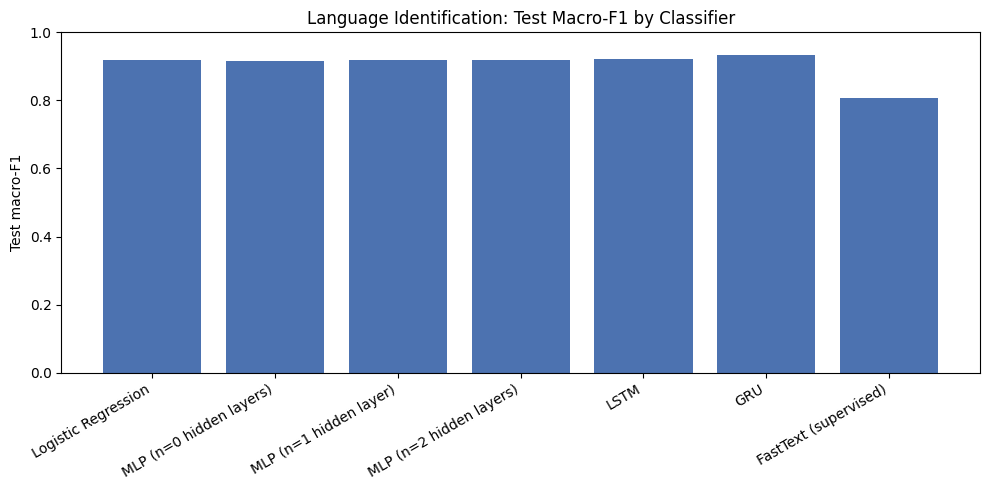

In [12]:
print(f"{'Model':<28}{'Val macro-F1':>15}{'Test macro-F1':>16}")
print("-" * 59)
for name, scores in results.items():
    print(f"{name:<28}{scores['val']:>15.4f}{scores['test']:>16.4f}")

best_model = max(results, key=lambda k: results[k]["test"])
print(f"\nBest model on test macro-F1: {best_model} ({results[best_model]['test']:.4f})")

names = list(results.keys())
plt.figure(figsize=(10, 5))
plt.bar(names, [results[n]["test"] for n in names], color="#4C72B0")
plt.ylabel("Test macro-F1")
plt.title("Language Identification: Test Macro-F1 by Classifier")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()